# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Parker Catena, Regina Velasco

**ID**: pdc76, rv297

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE 4750 /HW 3/hw3-parker`
Precompiling project...
    466.1 ms  ✓ WorkerUtilities
    472.1 ms  ✓ IteratorInterfaceExtensions
    471.7 ms  ✓ TensorCore
    536.2 ms  ✓ LaTeXStrings
    469.3 ms  ✓ Contour
    478.7 ms  ✓ StatsAPI
    356.6 ms  ✓ Measures
    918.2 ms  ✓ Format
    479.9 ms  ✓ Statistics
    503.9 ms  ✓ OrderedCollections
    653.6 ms  ✓ Grisu
    302.9 ms  ✓ DataValueInterfaces
    786.8 ms  ✓ FillArrays
    443.3 ms  ✓ Requires
    360.2 ms  ✓ StableRNGs
    443.3 ms  ✓ Unzip
    310.8 ms  ✓ Reexport
    502.0 ms  ✓ DocStringExtensions
    378.1 ms  ✓ SimpleBufferStream
    396.2 ms  ✓ PtrArrays
    612.3 ms  ✓ InlineStrings
    612.1 ms  ✓ URIs
   1750.5 ms  ✓ MacroTools
    411.4 ms  ✓ InvertedIndices
   1029.5 ms  ✓ IrrationalConstants
    499.4 ms  ✓ NaNMath
    475.3 ms  ✓ DelimitedFiles
    616.1 ms  ✓ TranscodingStreams
    421.0 ms  ✓ DataAPI
    355.2 ms  ✓ BitFlags
    376.4 ms  ✓ Scratch
    720.3 ms  ✓ ConcurrentUtilities
    9

In [2]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

$K_a = 0.55$ per day

$K_c = 0.35$ per day

$K_n = 0.25$ per day

$C_s = 10$ mg/L

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Minimum DO = 3.756 mg/L at x = 22.35 km


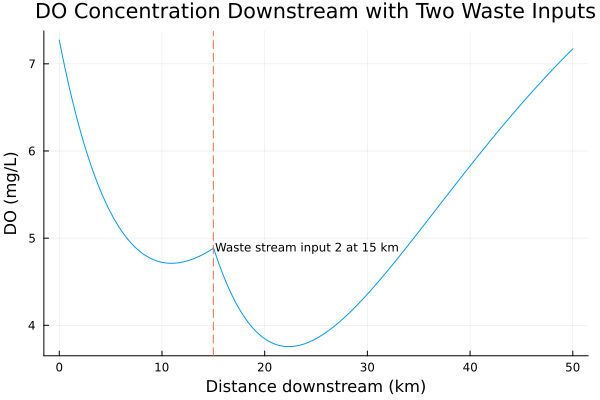

In [ ]:
u = 6 #km/day
dist = 15 #km
r = 0.55 #1/day
kc = 0.35 #1/day
kn = 0.25 #1/day
Cs = 10 #mg/L

Q_r0 = 100000 #m3/day
DO_r0 = 7.5 #mg/L
C_r0 = 5 #mg/L
N_r0 = 5 #mg/L

Q_w1 = 10000 #m3/day
DO_w1 = 5 #mg/L
C_w1 = 50 #mg/L
N_w1 = 35 #mg/L

Q_w2 = 15000 #m3/day
DO_w2 = 5 #mg/L
C_w2 = 45 #mg/L
N_w2 = 35 #mg/L

Q_out1 = Q_r0 + Q_w1 

function conc_initial(c0, q0, c1, q1, qout)
    ((c0*q0) + (c1*q1)) / qout
end

DO_out1 = conc_initial(DO_r0, Q_r0, DO_w1, Q_w1, Q_out1)
C_out1  = conc_initial(C_r0,  Q_r0, C_w1,  Q_w1, Q_out1)
N_out1  = conc_initial(N_r0,  Q_r0, N_w1,  Q_w1, Q_out1)

function conc(x, u, r, kc, kn, DO0, C0, N0, Cs)
    a1 = exp(-r*x/u)
    a2 = (kc/(r-kc))*(exp(-kc*x/u) - a1)
    a3 = (kn/(r-kn))*(exp(-kn*x/u) - a1)
    Cs*(1 - a1) + DO0*a1 - C0*a2 - N0*a3
end

# UNTIL X = 15 RIGHT BEFORE SECOND WASTE STREAM INPUT
x1 = range(0.0, stop=15.0, length=1501)           # <- use 0..15 here
C1 = conc.(x1, u, r, kc, kn, DO_out1, C_out1, N_out1, Cs)

# values at x=15
# (L0 and N0 were undefined; you meant the mixed CBOD/NBOD after the first discharge)
L15 = C_out1 * exp(-kc*15.0/u)                    # scalar math is fine
N15 = N_out1 * exp(-kn*15.0/u)
C15 = C1[end]                                     # indexing uses [end], not C1(end)

# SECOND WASTE STREAM INPUT AT X = 15 
Q_out2 = Q_out1 + Q_w2
DO_out2 = conc_initial(C15, Q_out1, DO_w2, Q_w2, Q_out2)
C_out2  = conc_initial(L15,  Q_out1, C_w2,  Q_w2, Q_out2)  
N_out2  = conc_initial(N15,  Q_out1, N_w2,  Q_w2, Q_out2)  

x2 = range(15.0, stop=50.0, length=3501)
C2 = conc.(x2 .- 15.0, u, r, kc, kn, DO_out2, C_out2, N_out2, Cs)

x_total = [x1; x2[2:end]]
C_total = [C1; C2[2:end]]
imin = argmin(C_total)
minDO = C_total[imin]
x_at_min = x_total[imin]
println("Minimum DO = $(round(minDO, digits=3)) mg/L at x = $(round(x_at_min, digits=3)) km")

# plot
plot(x_total, C_total, xlabel = "Distance downstream (km)", ylabel = "DO (mg/L)",
     title = "DO Concentration Downstream with Two Waste Inputs", legend = false)
vline!([15.0], linestyle = :dash)
annotate!(15.2, DO_out2, text("Waste stream input 2 at 15 km", :left, 8))




### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

## References

List any external references consulted, including classmates.